# Ternary Simplex Visualizations
Five visualization approaches for 3-model soup accuracy landscapes.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import mpltern

plt.style.use("style.mplstyle")

# Load dummy data (swap path to real data when ready)
df = pd.read_parquet('../analysis/ternary/ternary_240_3_170_2_250_4.parquet')
t, l, r = df["w1"].values, df["w2"].values, df["w3"].values
acc = df["accuracy"].values
key_a, key_b, key_c = df.iloc[0][["key_a", "key_b", "key_c"]]

print(f"Triplet: ({key_a}, {key_b}, {key_c})")
print(f"{len(df)} grid points, acc range: {acc.min():.2f} – {acc.max():.2f}")

Triplet: (240_3, 170_2, 250_4)
231 grid points, acc range: 68.17 – 78.58


## 1. Filled Contour (tricontourf)
Smooth filled contours — the standard for continuous scalar fields on simplices. Clean, familiar, easy to read.

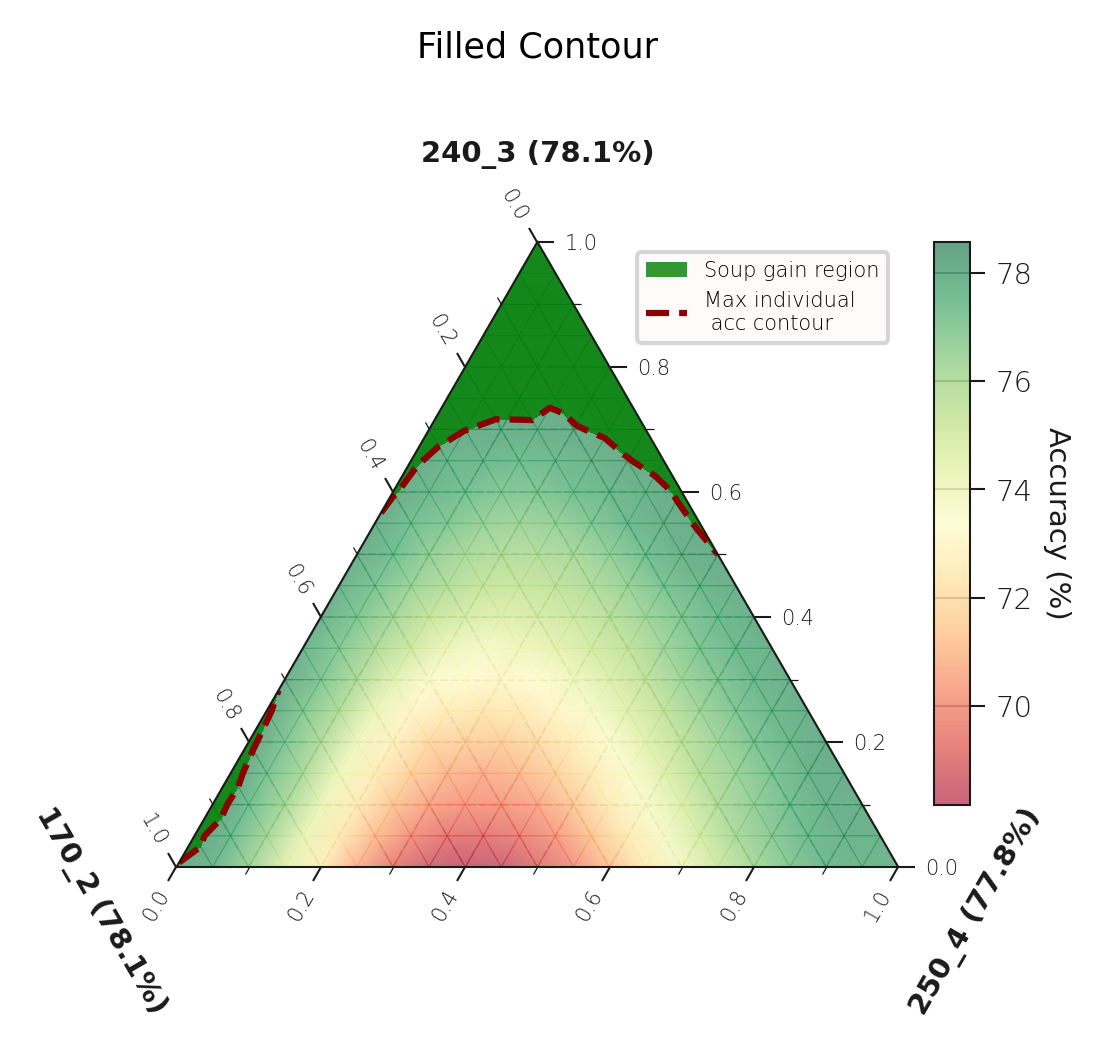

In [37]:
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(4, 3.5))
ax = fig.add_subplot(111, projection="ternary")

# Smooth color gradient via tripcolor, then contour lines with labels on top
cs = ax.tripcolor(t, l, r, acc, alpha=0.6, cmap="RdYlGn", shading="gouraud", rasterized=True, edgecolors='none')
levels = np.linspace(acc.min(), acc.max(), 12)

# Highlight region where soup beats all 3 individual models
corner_acc_t = acc[np.isclose(t, 1.0) & np.isclose(l, 0.0) & np.isclose(r, 0.0)][0]
corner_acc_l = acc[np.isclose(t, 0.0) & np.isclose(l, 1.0) & np.isclose(r, 0.0)][0]
corner_acc_r = acc[np.isclose(t, 0.0) & np.isclose(l, 0.0) & np.isclose(r, 1.0)][0]
best_individual = max(corner_acc_t, corner_acc_l, corner_acc_r)

# Semi-transparent pink overlay for "soup wins" region
ax.tricontourf(t, l, r, acc, levels=[best_individual, acc.max() + 1],
               colors=["green"], alpha=0.8)
# Bold dashed boundary contour
ax.tricontour(t, l, r, acc, levels=[best_individual],
              colors="darkred", linewidths=1.5, linestyles="--")

# Grid at 0.1 intervals (via minor), tick labels at 0.2 (via major)
for axis in [ax.taxis, ax.laxis, ax.raxis]:
    axis.set_major_locator(MultipleLocator(0.2))
    axis.set_minor_locator(MultipleLocator(0.1))

ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.5)
ax.tick_params(which="minor", length=2, width=0.3)
ax.tick_params(which="major", length=4, width=0.5, labelsize=5)

ax.set_tlabel(f"{key_a} ({corner_acc_t:.1f}%)", fontweight="bold")
ax.set_llabel(f"{key_b} ({corner_acc_l:.1f}%)", fontweight="bold")
ax.set_rlabel(f"{key_c} ({corner_acc_r:.1f}%)", fontweight="bold")

# Legend
legend_handles = [
    Patch(facecolor="green", alpha=0.8, label="Soup gain region"),
    Line2D([0], [0], color="darkred", linewidth=1.5, linestyle="--", label="Max individual\n acc contour"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=5, framealpha=0.8)

cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
cbar = fig.colorbar(cs, cax=cax)
cbar.set_label("Accuracy (%)", rotation=270, va="baseline")

ax.set_title("Filled Contour", pad=20)

plt.tight_layout()
plt.show()

## 2. Scatter with Size + Color Encoding
Each grid point is a dot — color maps accuracy, size maps soup gain (improvement over best individual model). Good for showing where synergy is strongest.

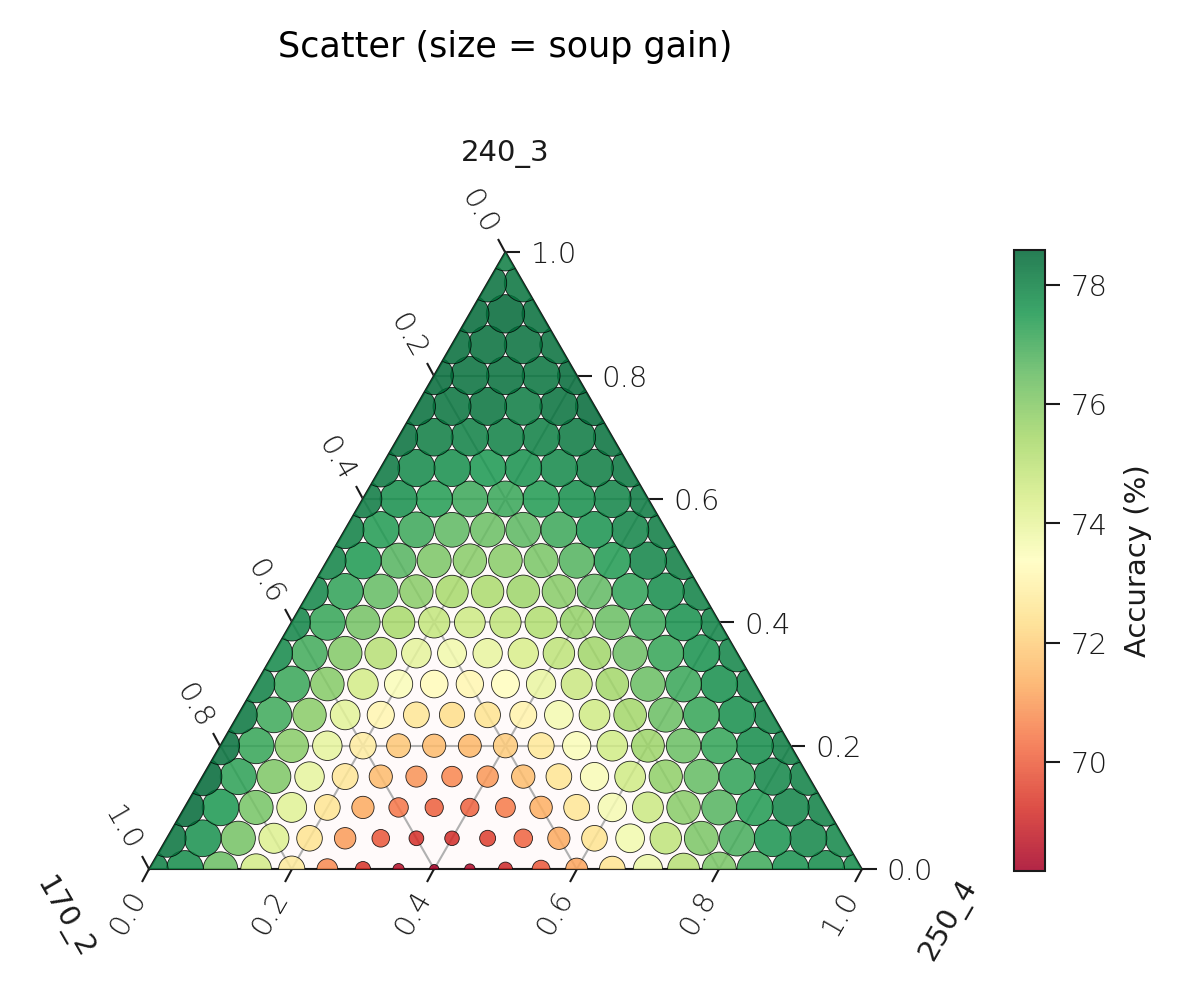

In [28]:
# Soup gain: actual acc minus best individual model *participating* in the blend
# On edges (one weight=0), compare vs best of the two active models
# In interior (all weights>0), compare vs best of all three
corners = {}
for _, row in df.iterrows():
    ws = (row["w1"], row["w2"], row["w3"])
    if ws == (1.0, 0.0, 0.0):
        corners["a"] = row["accuracy"]
    elif ws == (0.0, 1.0, 0.0):
        corners["b"] = row["accuracy"]
    elif ws == (0.0, 0.0, 1.0):
        corners["c"] = row["accuracy"]

corner_accs = np.array([corners["a"], corners["b"], corners["c"]])
active = np.column_stack([t > 0, l > 0, r > 0])  # which models participate
best_active = np.array([corner_accs[mask].max() for mask in active])
soup_gain = acc - best_active

fig = plt.figure(figsize=(4, 3.5))
ax = fig.add_subplot(111, projection="ternary")

sizes = 5 + 80 * (soup_gain - soup_gain.min()) / (soup_gain.max() - soup_gain.min())
sc = ax.scatter(t, l, r, c=acc, s=sizes, cmap="RdYlGn", edgecolors="k",
                linewidths=0.2, alpha=0.85, zorder=5)

cbar = fig.colorbar(sc, ax=ax, pad=0.15, shrink=0.7)
cbar.set_label("Accuracy (%)")

ax.set_tlabel(key_a)
ax.set_llabel(key_b)
ax.set_rlabel(key_c)
ax.set_title("Scatter (size = soup gain)", pad=20)

plt.tight_layout()
plt.show()

## 3. Tripcolor (Gouraud-shaded triangulation)
Interpolated color mesh — no contour lines, just smooth shading. Minimal and elegant, good for showing gradients.

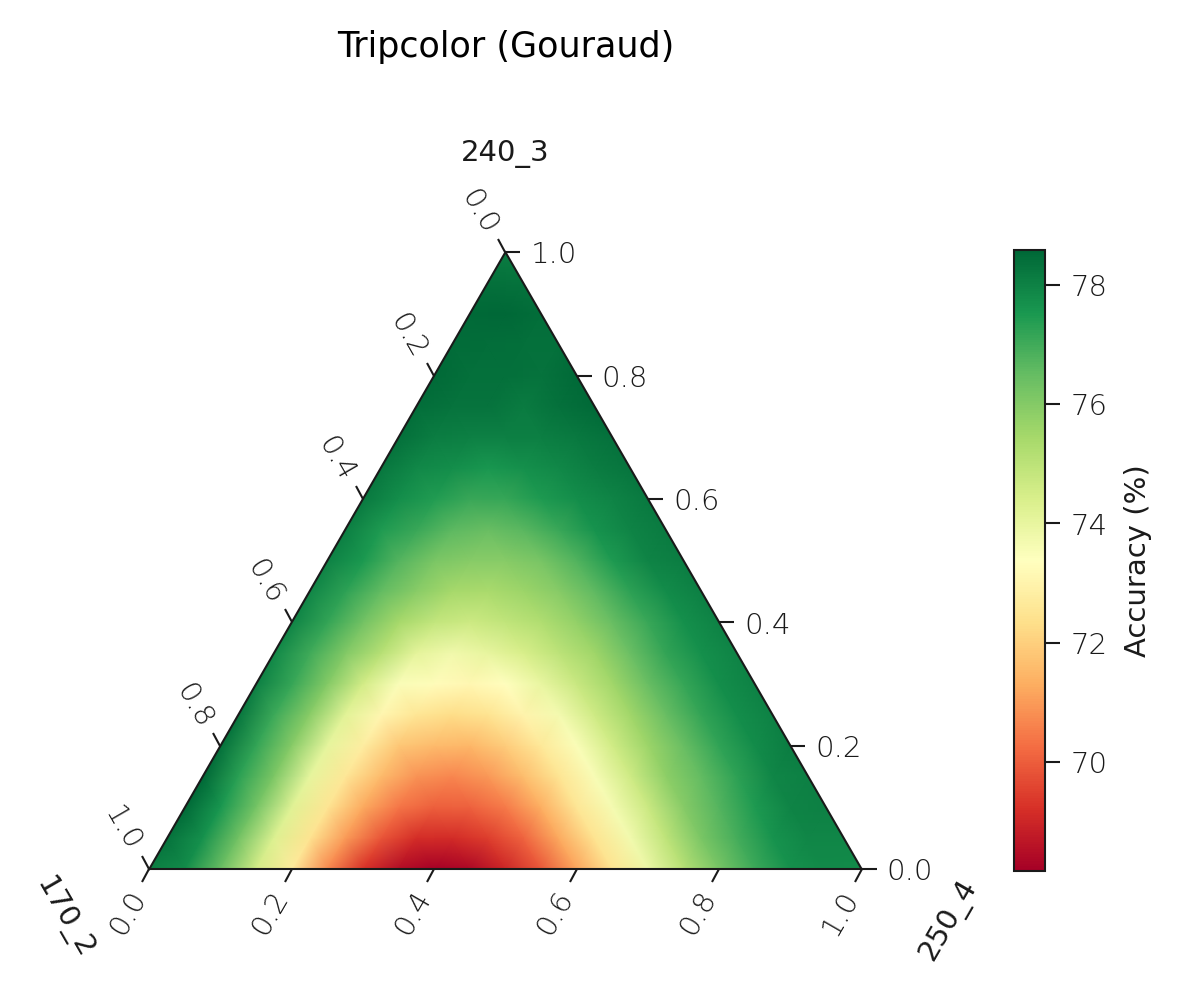

In [29]:
fig = plt.figure(figsize=(4, 3.5))
ax = fig.add_subplot(111, projection="ternary")

tc = ax.tripcolor(t, l, r, acc, shading="gouraud", cmap="RdYlGn")

cbar = fig.colorbar(tc, ax=ax, pad=0.15, shrink=0.7)
cbar.set_label("Accuracy (%)")

ax.set_tlabel(key_a)
ax.set_llabel(key_b)
ax.set_rlabel(key_c)
ax.set_title("Tripcolor (Gouraud)", pad=20)

plt.tight_layout()
plt.show()

## 4. Contour + Annotated Optimum
Line contours only (no fill) on white background — cleaner for print. Star marks the peak accuracy with annotation. More suitable if the paper is grayscale-friendly.

ValueError: too many values to unpack (expected 2)

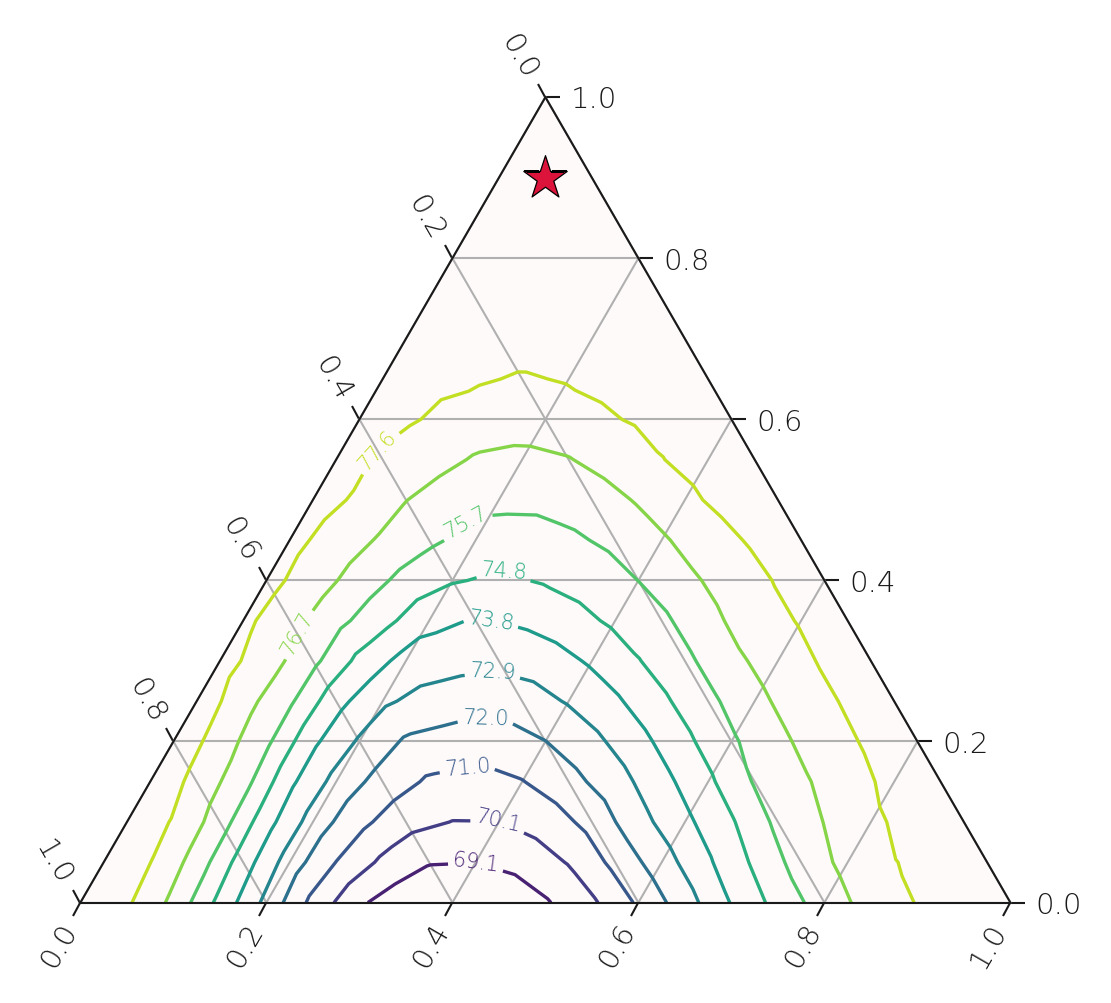

In [30]:
fig = plt.figure(figsize=(4, 3.5))
ax = fig.add_subplot(111, projection="ternary")

levels = np.linspace(acc.min(), acc.max(), 12)
cs = ax.tricontour(t, l, r, acc, levels=levels, cmap="viridis", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=5, fmt="%.1f")

# Mark optimum
best_idx = acc.argmax()
ax.scatter([t[best_idx]], [l[best_idx]], [r[best_idx]],
           marker="*", s=120, c="crimson", zorder=10, edgecolors="k", linewidths=0.3)
ax.annotate(f"{acc[best_idx]:.1f}%",
            xy=(t[best_idx], l[best_idx], r[best_idx]),
            xytext=(5, 5), textcoords="offset points", fontsize=6,
            color="crimson", fontweight="bold")

# Mark corners
for wt, wl, wr, label in [(1,0,0,key_a), (0,1,0,key_b), (0,0,1,key_c)]:
    mask = (t == wt) & (l == wl) & (r == wr)
    if mask.any():
        corner_acc = acc[mask][0]
        ax.scatter([wt], [wl], [wr], marker="o", s=30, c="k", zorder=10)
        ax.annotate(f"{corner_acc:.1f}%", xy=(wt, wl, wr),
                    xytext=(3, -8), textcoords="offset points", fontsize=5)

ax.set_tlabel(key_a)
ax.set_llabel(key_b)
ax.set_rlabel(key_c)
ax.set_title("Contour + Optimum", pad=20)

plt.tight_layout()
plt.show()

## 5. Diverging Colormap (Soup Gain)
Shows soup gain — improvement over the best individual model. Blue = underperforms best model alone, red = outperforms (synergy). Centers colormap at zero. Directly answers: 'where does model souping help?'

In [ ]:
# soup_gain already computed in cell 2
vmax = max(abs(soup_gain.min()), abs(soup_gain.max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig = plt.figure(figsize=(4, 3.5))
ax = fig.add_subplot(111, projection="ternary")

levels = np.linspace(-vmax, vmax, 15)
cs = ax.tricontourf(t, l, r, soup_gain, levels=levels, cmap="RdBu_r", norm=norm)
ax.tricontour(t, l, r, soup_gain, levels=[0], colors="k", linewidths=1.0, linestyles="--")

cbar = fig.colorbar(cs, ax=ax, pad=0.15, shrink=0.7)
cbar.set_label("Soup gain over best model (pp)")

ax.set_tlabel(key_a)
ax.set_llabel(key_b)
ax.set_rlabel(key_c)
ax.set_title("Soup Gain (diverging)", pad=20)

plt.tight_layout()
plt.show()

---
## Notes
- **1 (tricontourf)**: Best all-rounder for ICLR. Familiar, information-dense.
- **2 (scatter+size)**: Good for highlighting *where* synergy is, but noisy at high resolution.
- **3 (tripcolor)**: Cleanest/most minimal, but no contour lines to guide the eye.
- **4 (contour+annotated)**: Best for grayscale/print, explicit numeric annotations.
- **5 (diverging bonus)**: Best for the *story* — directly shows where souping beats linear interpolation.

Recommendation: Use **1** or **5** as the main figure. **5** is more novel and directly tells the transitivity story.